# BNCI2014_009 P300 benchmark summary

This notebook is the final Stage 7 report for the BNCI2014_009 staged run. It reads only immutable artifacts produced in Stages 1 and 4-6 and does not train or refit models.

Primary claim level: leave-one-subject-out subject generalization over 17,280 single post-stimulus P300 epochs, binary `Target` vs `NonTarget` labels, and ten held-out subjects.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)


## Source Artifacts

The report compares the completed classical ERP/xDAWN sweep, the raw ERP Torch sweep, and the exploratory FFT spectral Torch sweep. The FFT spectral run records Morlet, Superlet, and STFT as deferred because their existing project time-frequency contracts target longer epochs than this 0.8-second P300 task.


In [2]:
PROJECT_ROOT = Path.cwd()
for candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    audit_candidate = candidate / "artifacts/experiments/bnci2014_009/stage1_dataset_audit.json"
    if audit_candidate.is_file():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate BNCI2014_009 stage1 audit artifact from notebook cwd")

ROOT = PROJECT_ROOT / "artifacts/experiments/bnci2014_009"
AUDIT_PATH = ROOT / "stage1_dataset_audit.json"
CLASSICAL_DIR = ROOT / "classical-sweep" / "7b7a88206dd8d8a5"
RAW_TORCH_DIR = ROOT / "raw-erp-torch" / "7afe116a224e20e2"
SPECTRAL_TORCH_DIR = ROOT / "spectral-torch" / "8d4c3434245e4841"
SUMMARY_PATH = ROOT / "stage7_benchmark_summary.json"

required_paths = [
    AUDIT_PATH,
    CLASSICAL_DIR / "evaluation.json",
    CLASSICAL_DIR / "manifest.json",
    RAW_TORCH_DIR / "evaluation.json",
    RAW_TORCH_DIR / "comparison.json",
    RAW_TORCH_DIR / "manifest.json",
    SPECTRAL_TORCH_DIR / "evaluation.json",
    SPECTRAL_TORCH_DIR / "comparison.json",
    SPECTRAL_TORCH_DIR / "manifest.json",
]
for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(path)


def load_json(path: Path) -> dict:
    with path.open(encoding="utf-8") as file:
        payload = json.load(file)
    if not isinstance(payload, dict):
        raise TypeError(f"Expected object JSON: {path}")
    return payload


audit = load_json(AUDIT_PATH)
classical_eval = load_json(CLASSICAL_DIR / "evaluation.json")
raw_eval = load_json(RAW_TORCH_DIR / "evaluation.json")
raw_comparison = load_json(RAW_TORCH_DIR / "comparison.json")
spectral_eval = load_json(SPECTRAL_TORCH_DIR / "evaluation.json")
spectral_comparison = load_json(SPECTRAL_TORCH_DIR / "comparison.json")

source_table = pd.DataFrame(
    [
        {"stage": "1", "family": "dataset_audit", "path": AUDIT_PATH.relative_to(PROJECT_ROOT).as_posix()},
        {"stage": "4", "family": "classical", "path": CLASSICAL_DIR.relative_to(PROJECT_ROOT).as_posix()},
        {"stage": "5", "family": "raw_torch", "path": RAW_TORCH_DIR.relative_to(PROJECT_ROOT).as_posix()},
        {"stage": "6", "family": "spectral_torch", "path": SPECTRAL_TORCH_DIR.relative_to(PROJECT_ROOT).as_posix()},
    ]
)
source_table


,stage,family,path
0,1,dataset_audit,artifacts/experiments/bnci2014_009/stage1_data...
1,4,classical,artifacts/experiments/bnci2014_009/classical-s...
2,5,raw_torch,artifacts/experiments/bnci2014_009/raw-erp-tor...
3,6,spectral_torch,artifacts/experiments/bnci2014_009/spectral-to...


## Contract Checks

These checks are intentionally strict. The final report should fail if class order, fold count, sample count, or Stage 5/6 split alignment changes unexpectedly.


In [3]:
EXPECTED_CLASSES = ["Target", "NonTarget"]
EXPECTED_N_FOLDS = 10
EXPECTED_N_SAMPLES = 17280
EXPECTED_FOLD_SAMPLES = 1728
EXPECTED_TARGET_PER_FOLD = 288
EXPECTED_NON_TARGET_PER_FOLD = 1440

assert classical_eval["class_names"] == EXPECTED_CLASSES
assert raw_eval["class_names"] == EXPECTED_CLASSES
assert spectral_eval["class_names"] == EXPECTED_CLASSES
assert audit["static_summary"]["n_subjects"] == 10
assert audit["static_summary"]["n_channels"] == 16
assert audit["static_summary"]["sampling_rate_hz"] == 256.0
assert audit["static_summary"]["interval_seconds"] == [0, 0.8]

all_variants = classical_eval["variants"] + raw_eval["variants"] + spectral_eval["variants"]
for variant in all_variants:
    summary = variant["summary"]
    assert summary["n_folds"] == EXPECTED_N_FOLDS
    assert summary["n_samples"] == EXPECTED_N_SAMPLES
    fold_subjects = [int(fold["test_subjects"][0]) for fold in variant["folds"]]
    assert fold_subjects == list(range(1, 11))
    for fold in variant["folds"]:
        assert fold["metrics"]["n_samples"] == EXPECTED_FOLD_SAMPLES
        matrix = np.asarray(fold["metrics"]["confusion_matrix"], dtype=int)
        assert matrix.shape == (2, 2)
        assert matrix[0].sum() == EXPECTED_TARGET_PER_FOLD
        assert matrix[1].sum() == EXPECTED_NON_TARGET_PER_FOLD

assert spectral_comparison["raw_split_alignment"]["matches_raw_test_indices"] is True
assert {item["method"] for item in spectral_comparison["deferred_methods"]} == {"morlet", "superlet", "stft"}

contract = {
    "dataset": "BNCI2014_009",
    "classes": EXPECTED_CLASSES,
    "n_subjects": 10,
    "n_epochs": EXPECTED_N_SAMPLES,
    "n_folds": EXPECTED_N_FOLDS,
    "fold_test_samples": EXPECTED_FOLD_SAMPLES,
    "target_per_test_fold": EXPECTED_TARGET_PER_FOLD,
    "non_target_per_test_fold": EXPECTED_NON_TARGET_PER_FOLD,
    "primary_protocol": "leave-one-subject-out",
    "prediction_unit": "single post-stimulus P300 epoch",
    "raw_spectral_split_aligned": True,
}
contract


{'dataset': 'BNCI2014_009',
 'classes': ['Target', 'NonTarget'],
 'n_subjects': 10,
 'n_epochs': 17280,
 'n_folds': 10,
 'fold_test_samples': 1728,
 'target_per_test_fold': 288,
 'non_target_per_test_fold': 1440,
 'primary_protocol': 'leave-one-subject-out',
 'prediction_unit': 'single post-stimulus P300 epoch',
 'raw_spectral_split_aligned': True}

## Aggregate Ranking

Balanced accuracy is the primary metric because the test set is strongly imbalanced: each held-out subject contributes 288 `Target` and 1,440 `NonTarget` epochs.


In [4]:
def summary_row(variant: dict, family: str) -> dict:
    summary = variant["summary"]
    return {
        "model_id": variant["model_id"],
        "family": family,
        "architecture": variant.get("architecture"),
        "method": variant.get("method") or ("erp/xDAWN" if family == "classical" else "raw_erp"),
        "balanced_accuracy_mean": summary["balanced_accuracy_mean"],
        "balanced_accuracy_std": summary["balanced_accuracy_std"],
        "macro_f1_mean": summary["macro_f1_mean"],
        "target_recall_mean": summary["target_recall_mean"],
        "non_target_recall_mean": summary["non_target_recall_mean"],
        "roc_auc_mean": summary["roc_auc_mean"],
        "pr_auc_mean": summary["pr_auc_mean"],
        "n_folds": summary["n_folds"],
        "n_samples": summary["n_samples"],
    }

rows = []
rows.extend(summary_row(variant, "classical") for variant in classical_eval["variants"])
rows.extend(summary_row(variant, "raw_torch") for variant in raw_eval["variants"])
rows.extend(summary_row(variant, "spectral_torch") for variant in spectral_eval["variants"])

ranking = pd.DataFrame(rows).sort_values("balanced_accuracy_mean", ascending=False).reset_index(drop=True)
best_classical = ranking[ranking["family"] == "classical"].iloc[0]
best_raw = ranking[ranking["family"] == "raw_torch"].iloc[0]
best_spectral = ranking[ranking["family"] == "spectral_torch"].iloc[0]
ranking["delta_vs_best_classical"] = ranking["balanced_accuracy_mean"] - float(best_classical["balanced_accuracy_mean"])
ranking["delta_vs_best_raw_torch"] = ranking["balanced_accuracy_mean"] - float(best_raw["balanced_accuracy_mean"])
ranking


,model_id,family,architecture,method,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,target_recall_mean,non_target_recall_mean,roc_auc_mean,pr_auc_mean,n_folds,n_samples,delta_vs_best_classical,delta_vs_best_raw_torch
0,erp-logreg,classical,NaN,erp/xDAWN,0.764062,0.058843,0.711260,0.700347,0.827778,0.850690,0.594067,10,17280,0.000000,0.147917
1,erp-ridge,classical,NaN,erp/xDAWN,0.760556,0.059768,0.709375,0.693056,0.828056,0.845429,0.582349,10,17280,-0.003507,0.144410
2,xdawn-tangent-logreg,classical,NaN,erp/xDAWN,0.755486,0.045539,0.712299,0.670833,0.840139,0.858303,0.590883,10,17280,-0.008576,0.139340
3,erp-linear-svm,classical,NaN,erp/xDAWN,0.728403,0.053740,0.668772,0.668750,0.788056,0.811880,0.519027,10,17280,-0.035660,0.112257
4,erp-lda,classical,NaN,erp/xDAWN,0.691771,0.082109,0.705968,0.432986,0.950556,0.865505,0.627119,10,17280,-0.072292,0.075625
5,xdawn-tangent-lda,classical,NaN,erp/xDAWN,0.653299,0.083550,0.670123,0.342708,0.963889,0.853867,0.587138,10,17280,-0.110764,0.037153
6,deep-convnet-raw-erp,raw_torch,deep-convnet,raw_erp,0.616146,0.061481,0.555937,0.499306,0.732986,0.685292,0.347924,10,17280,-0.147917,0.000000
7,raw-cnn-raw-erp,raw_torch,raw-cnn,raw_erp,0.579514,0.034969,0.504183,0.520139,0.638889,0.631378,0.292536,10,17280,-0.184549,-0.036632
8,shallow-convnet-raw-erp,raw_torch,shallow-convnet,raw_erp,0.558299,0.031314,0.510265,0.417708,0.698889,0.596401,0.244490,10,17280,-0.205764,-0.057847
9,eegnet-fft-spectral,spectral_torch,eegnet,fft,0.552674,0.045259,0.540620,0.197222,0.908125,0.597312,0.268066,10,17280,-0.211389,-0.063472


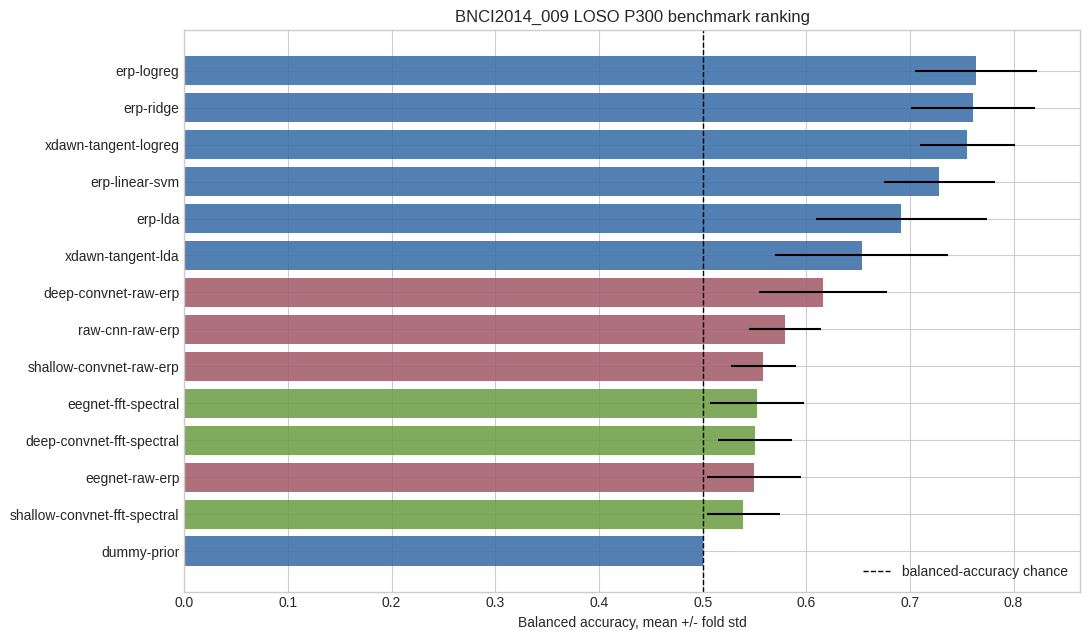

In [5]:
fig, ax = plt.subplots(figsize=(11, 6.5))
plot_df = ranking.sort_values("balanced_accuracy_mean", ascending=True)
colors = plot_df["family"].map({"classical": "#3b6ea8", "raw_torch": "#a35d6a", "spectral_torch": "#6f9e47"})
ax.barh(
    plot_df["model_id"],
    plot_df["balanced_accuracy_mean"],
    xerr=plot_df["balanced_accuracy_std"],
    color=colors,
    alpha=0.88,
)
ax.axvline(0.5, color="black", linestyle="--", linewidth=1, label="balanced-accuracy chance")
ax.set_xlabel("Balanced accuracy, mean +/- fold std")
ax.set_ylabel("")
ax.set_title("BNCI2014_009 LOSO P300 benchmark ranking")
ax.legend(loc="lower right")
fig.tight_layout()


## Family View

The strongest model family is classical ERP/xDAWN. Raw ERP deep models improve over the exploratory FFT spectral deep models in this compact untuned setup, but neither neural family reaches the fixed ERP Logistic Regression baseline.


In [6]:
family_summary = (
    ranking.groupby("family", as_index=False)
    .agg(
        best_balanced_accuracy=("balanced_accuracy_mean", "max"),
        mean_balanced_accuracy=("balanced_accuracy_mean", "mean"),
        best_target_recall=("target_recall_mean", "max"),
        n_models=("model_id", "count"),
    )
    .sort_values("best_balanced_accuracy", ascending=False)
)
family_summary


,family,best_balanced_accuracy,mean_balanced_accuracy,best_target_recall,n_models
0,classical,0.764062,0.693368,0.700347,7
1,raw_torch,0.616146,0.575859,0.520139,4
2,spectral_torch,0.552674,0.547500,0.363194,3


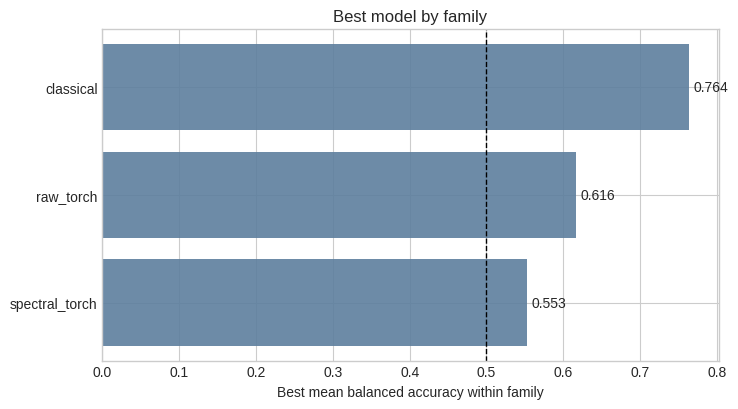

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
family_plot = family_summary.sort_values("best_balanced_accuracy")
ax.barh(family_plot["family"], family_plot["best_balanced_accuracy"], color="#5d7f9e", alpha=0.9)
ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Best mean balanced accuracy within family")
ax.set_ylabel("")
ax.set_title("Best model by family")
for y, value in enumerate(family_plot["best_balanced_accuracy"]):
    ax.text(value + 0.006, y, f"{value:.3f}", va="center")
fig.tight_layout()


## Held-Out Subject Variability

The comparison below shows the strongest classical, raw ERP deep, and FFT spectral models on the same ten held-out subjects.


In [8]:
def find_variant(evaluation: dict, model_id: str) -> dict:
    return next(variant for variant in evaluation["variants"] if variant["model_id"] == model_id)

best_classical_variant = find_variant(classical_eval, str(best_classical["model_id"]))
best_raw_variant = find_variant(raw_eval, str(best_raw["model_id"]))
best_spectral_variant = find_variant(spectral_eval, str(best_spectral["model_id"]))


def fold_rows(model_id: str, family: str, folds: list[dict]) -> list[dict]:
    result = []
    for fold in folds:
        result.append(
            {
                "model_id": model_id,
                "family": family,
                "subject": int(fold["test_subjects"][0]),
                "balanced_accuracy": fold["metrics"]["balanced_accuracy"],
                "target_recall": fold["metrics"]["target_recall"],
                "macro_f1": fold["metrics"]["macro_f1"],
            }
        )
    return result

fold_df = pd.DataFrame(
    fold_rows(str(best_classical["model_id"]), "classical", best_classical_variant["folds"])
    + fold_rows(str(best_raw["model_id"]), "raw_torch", best_raw_variant["folds"])
    + fold_rows(str(best_spectral["model_id"]), "spectral_torch", best_spectral_variant["folds"])
)
fold_df.pivot(index="subject", columns="model_id", values="balanced_accuracy")


model_id,deep-convnet-raw-erp,eegnet-fft-spectral,erp-logreg
subject,,,
1,0.537500,0.500000,0.701389
2,0.613542,0.500694,0.771875
3,0.604514,0.545139,0.765278
4,0.626389,0.557292,0.783333
5,0.715278,0.582986,0.840625
6,0.540625,0.553472,0.708681
7,0.537500,0.545486,0.680903
8,0.615972,0.531597,0.709722
9,0.693750,0.668403,0.831944


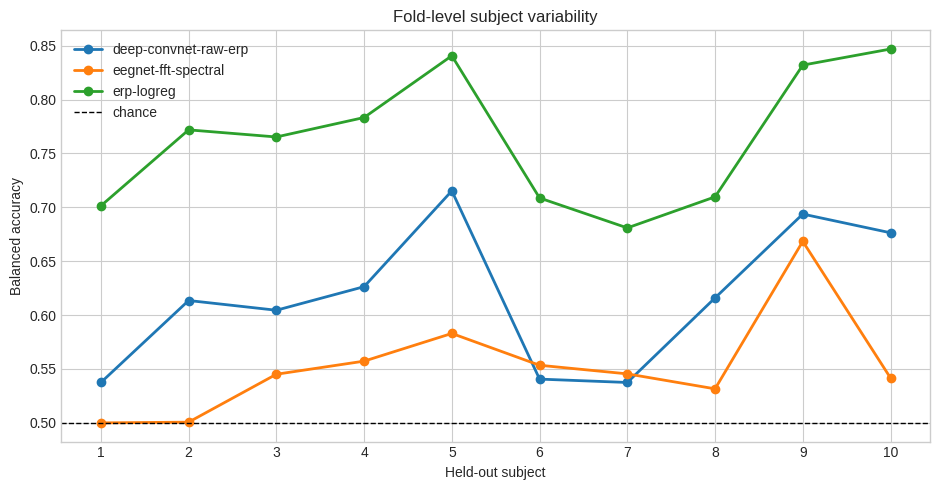

In [9]:
fig, ax = plt.subplots(figsize=(9.5, 5.0))
for model_id, group in fold_df.groupby("model_id"):
    group = group.sort_values("subject")
    ax.plot(group["subject"], group["balanced_accuracy"], marker="o", linewidth=2, label=model_id)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1, label="chance")
ax.set_xticks(sorted(fold_df["subject"].unique()))
ax.set_xlabel("Held-out subject")
ax.set_ylabel("Balanced accuracy")
ax.set_title("Fold-level subject variability")
ax.legend(loc="best")
fig.tight_layout()


## Target Recall And Score Metrics

For single-epoch P300 detection, target recall is an important secondary view: a high non-target accuracy alone can hide missed target flashes. ROC-AUC and PR-AUC are reported only from models that provide continuous target scores.


In [10]:
metric_view = ranking[
    [
        "model_id",
        "family",
        "balanced_accuracy_mean",
        "target_recall_mean",
        "non_target_recall_mean",
        "roc_auc_mean",
        "pr_auc_mean",
    ]
].copy()
metric_view.head(12)


,model_id,family,balanced_accuracy_mean,target_recall_mean,non_target_recall_mean,roc_auc_mean,pr_auc_mean
0,erp-logreg,classical,0.764062,0.700347,0.827778,0.850690,0.594067
1,erp-ridge,classical,0.760556,0.693056,0.828056,0.845429,0.582349
2,xdawn-tangent-logreg,classical,0.755486,0.670833,0.840139,0.858303,0.590883
3,erp-linear-svm,classical,0.728403,0.668750,0.788056,0.811880,0.519027
4,erp-lda,classical,0.691771,0.432986,0.950556,0.865505,0.627119
5,xdawn-tangent-lda,classical,0.653299,0.342708,0.963889,0.853867,0.587138
6,deep-convnet-raw-erp,raw_torch,0.616146,0.499306,0.732986,0.685292,0.347924
7,raw-cnn-raw-erp,raw_torch,0.579514,0.520139,0.638889,0.631378,0.292536
8,shallow-convnet-raw-erp,raw_torch,0.558299,0.417708,0.698889,0.596401,0.244490
9,eegnet-fft-spectral,spectral_torch,0.552674,0.197222,0.908125,0.597312,0.268066


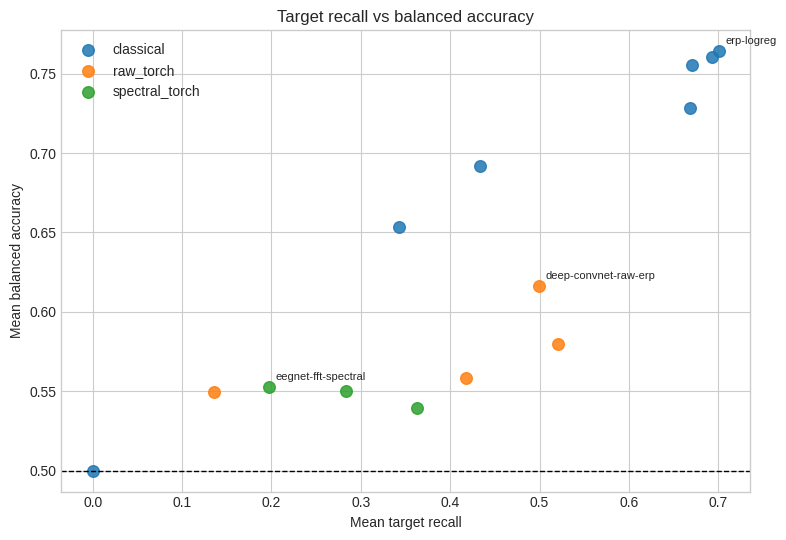

In [11]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for family, group in ranking.groupby("family"):
    ax.scatter(
        group["target_recall_mean"],
        group["balanced_accuracy_mean"],
        s=70,
        alpha=0.85,
        label=family,
    )
    for _, row in group.iterrows():
        if row["model_id"] in {best_classical["model_id"], best_raw["model_id"], best_spectral["model_id"]}:
            ax.annotate(row["model_id"], (row["target_recall_mean"], row["balanced_accuracy_mean"]), xytext=(5, 5), textcoords="offset points", fontsize=8)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Mean target recall")
ax.set_ylabel("Mean balanced accuracy")
ax.set_title("Target recall vs balanced accuracy")
ax.legend(loc="best")
fig.tight_layout()


## Aggregate Confusion Matrices

Matrices are row-normalized for readability. Rows are true labels; columns are predicted labels.


Text(0.5, 1.03, 'Aggregate confusion matrices for best models')

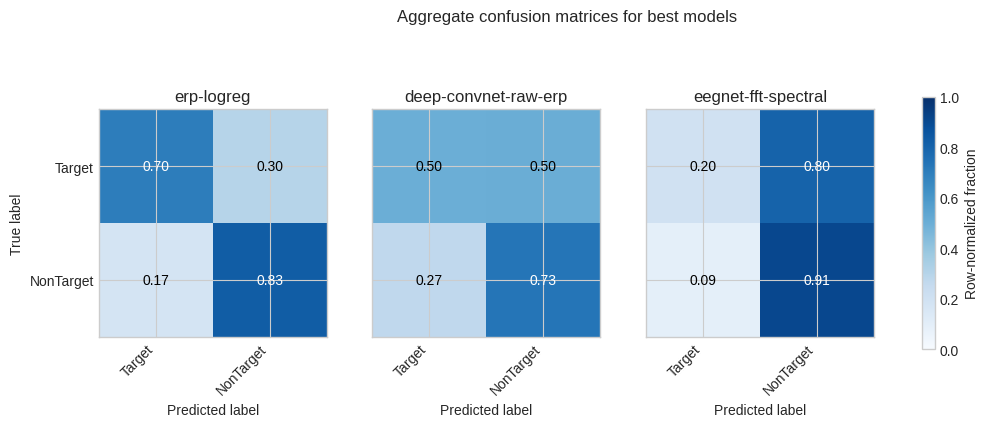

In [12]:
def row_normalized(matrix: list[list[int]]) -> np.ndarray:
    values = np.asarray(matrix, dtype=float)
    return values / values.sum(axis=1, keepdims=True)

confusions = {
    str(best_classical["model_id"]): best_classical_variant["summary"]["confusion_matrix"],
    str(best_raw["model_id"]): best_raw_variant["summary"]["confusion_matrix"],
    str(best_spectral["model_id"]): best_spectral_variant["summary"]["confusion_matrix"],
}

fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.0), sharex=True, sharey=True)
for ax, (title, matrix) in zip(axes, confusions.items(), strict=True):
    normalized = row_normalized(matrix)
    image = ax.imshow(normalized, cmap="Blues", vmin=0.0, vmax=1.0)
    ax.set_title(title)
    ax.set_xticks(np.arange(len(EXPECTED_CLASSES)), EXPECTED_CLASSES, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(EXPECTED_CLASSES)), EXPECTED_CLASSES)
    for i in range(normalized.shape[0]):
        for j in range(normalized.shape[1]):
            value = normalized[i, j]
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="white" if value > 0.55 else "black")
axes[0].set_ylabel("True label")
for ax in axes:
    ax.set_xlabel("Predicted label")
fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.82, label="Row-normalized fraction")
fig.suptitle("Aggregate confusion matrices for best models", y=1.03)


## Limitations

This benchmark is a single-epoch P300 target-detection benchmark, not a character-level spelling reconstruction. Classical methods use fixed settings; neural results are compact one-seed baselines with early stopping and no broad hyperparameter search. The FFT spectral run is exploratory, while Morlet/Superlet/STFT require a separate P300-specific time-frequency contract before training.


In [13]:
limitations = {
    "single_epoch_only": True,
    "not_character_level_spelling": True,
    "neural_runs_untuned": True,
    "spectral_fft_only": True,
    "deferred_time_frequency_methods": spectral_comparison["deferred_methods"],
    "primary_interpretation": "ERP Logistic Regression is the strongest completed BNCI2014_009 benchmark in this staged run.",
}
limitations


{'single_epoch_only': True,
 'not_character_level_spelling': True,
 'neural_runs_untuned': True,
 'spectral_fft_only': True,
 'deferred_time_frequency_methods': [{'method': 'morlet',
   'reason': 'Deferred from Stage 6 because the default project time-frequency contracts were designed for longer epochs; P300-specific windows should be introduced only with a separate validated tensor contract.'},
  {'method': 'superlet',
   'reason': 'Deferred from Stage 6 because the default project time-frequency contracts were designed for longer epochs; P300-specific windows should be introduced only with a separate validated tensor contract.'},
  {'method': 'stft',
   'reason': 'Deferred from Stage 6 because the default project time-frequency contracts were designed for longer epochs; P300-specific windows should be introduced only with a separate validated tensor contract.'}],
 'primary_interpretation': 'ERP Logistic Regression is the strongest completed BNCI2014_009 benchmark in this staged run.'

## Stage 7 Conclusion

The BNCI2014_009 adapter and benchmark pipeline are reproducible end to end. The strongest completed result is the classical `erp-logreg` baseline. Raw ERP neural models and FFT spectral neural models are useful exploratory comparisons, but neither improves on the classical ERP baseline in this staged run.


In [14]:
def json_clean(value):
    if isinstance(value, dict):
        return {key: json_clean(item) for key, item in value.items()}
    if isinstance(value, list):
        return [json_clean(item) for item in value]
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.floating):
        return float(value)
    if isinstance(value, float) and np.isnan(value):
        return None
    return value

best_overall = json_clean(ranking.iloc[0].to_dict())
best_classical_row = json_clean(best_classical.to_dict())
best_raw_row = json_clean(best_raw.to_dict())
best_spectral_row = json_clean(best_spectral.to_dict())
stage7_summary = {
    "stage": "7 - Final Notebook, Report, And Memory Update",
    "marker": "BNCI2014_009_BENCHMARK_VERIFIED",
    "contract": contract,
    "best_overall": best_overall,
    "best_classical": best_classical_row,
    "best_raw_torch": best_raw_row,
    "best_spectral_torch": best_spectral_row,
    "best_raw_delta_vs_best_classical": float(best_raw["balanced_accuracy_mean"] - best_classical["balanced_accuracy_mean"]),
    "best_spectral_delta_vs_best_classical": float(best_spectral["balanced_accuracy_mean"] - best_classical["balanced_accuracy_mean"]),
    "best_spectral_delta_vs_best_raw_torch": float(best_spectral["balanced_accuracy_mean"] - best_raw["balanced_accuracy_mean"]),
    "source_artifacts": source_table.to_dict(orient="records"),
    "ranking": json_clean(ranking.to_dict(orient="records")),
    "family_summary": json_clean(family_summary.to_dict(orient="records")),
    "limitations": json_clean(limitations),
}
SUMMARY_PATH.parent.mkdir(parents=True, exist_ok=True)
SUMMARY_PATH.write_text(json.dumps(stage7_summary, indent=2, sort_keys=True, allow_nan=False) + "\n", encoding="utf-8")
print("BNCI2014_009_BENCHMARK_VERIFIED")
print(json.dumps({"summary_path": SUMMARY_PATH.relative_to(PROJECT_ROOT).as_posix(), "best_overall": best_overall["model_id"]}, sort_keys=True))

BNCI2014_009_BENCHMARK_VERIFIED
{"best_overall": "erp-logreg", "summary_path": "artifacts/experiments/bnci2014_009/stage7_benchmark_summary.json"}
